In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

In [3]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.lfp import traces as lt
from GridMaze.analysis.lfp import theta_mod as tm
from GridMaze.analysis.distance_to_goal import theta_mod_decoder as tmd

# characterise mFC theta 

In [4]:
# example session for looking at LFP
session = gs.get_maze_sessions(
    subject_IDs=["m3"],
    maze_names=["maze_1"],
    days_on_maze=[12],
    with_data=["lfp_signal", "lfp_times", "lfp_metrics", "cluster_metrics"],
    must_have_data=True,
)

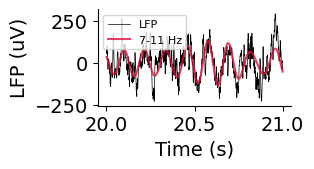

In [5]:
reload(lt)
f1, ax = plt.subplots(1, 1, figsize=(2.5, 1.25))
lt.plot_lfp_with_osc(session, window=(20, 21), freq_range=(7, 11), N=4, ax=ax)
# f1.savefig("../results/distance_to_goal/figures/main/lfp_example.pdf")

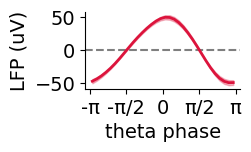

In [6]:
# similar to previous work we see the mFC cells are modulated by theta phase
reload(tm)
theta_aligned_signal = tm.get_theta_aligned_lfp_df()
f2, ax = plt.subplots(1, 1, figsize=(2, 1))
tm.plot_theta_aligned_lfp(theta_aligned_signal, ax=ax)
# f2.savefig("../results/distance_to_goal/figures/main/theta_aligned_lfp.pdf")

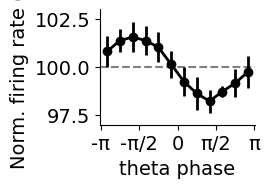

In [7]:
reload(tm)
population_theta_df = tm.get_population_theta_mod()
f3, ax = plt.subplots(1, 1, figsize=(2, 1.5))
tm.plot_population_theta_mod(population_theta_df, ax=ax)
# f3.savefig("../results/distance_to_goal/figures/main/population_theta_mod.pdf")

# Test theta modulation of distance-to-goal signal via decoding framework

In [8]:
theta_mod_decoding = tmd.load_decoding_results(lfp_type="theta_mid")

                  T2         F  df1  df2      pval
hotelling  16.323042  7.345369    2    9  0.012838


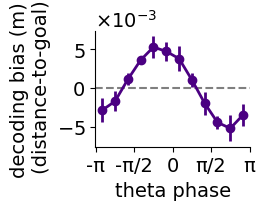

In [9]:
reload(tmd)
f4, ax = plt.subplots(1, 1, figsize=(2, 1.5))
tmd.plot_decoding_theta_bias(theta_mod_decoding, ax=ax, print_stats=True)
# f4.savefig("../results/distance_to_goal/figures/main/theta_mod_distance_decoding.pdf")

# Test theta modulation of distance-to-goal via tuning curve framework

In [10]:
# lets look at theta modulation in another way: tuning curves
from GridMaze.analysis.distance_to_goal import theta_mod_tuning as tmt

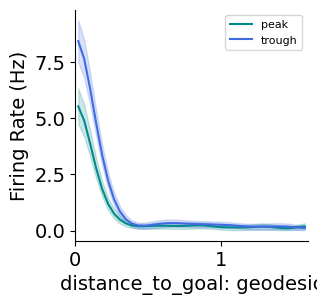

In [11]:
from GridMaze.analysis.core import get_clusters as gc

reload(gc)
Cluster = gc.get_cluster("m2.2022-07-04.maze_cluster34")
f, ax = plt.subplots(1, 1, figsize=(3, 3))
Cluster.plot_tuning(feature="distance_to_goal_theta", ax=ax)
# f.savefig("../results/distance_to_goal/figures/supp/example_theta_mod_tuning.pdf")

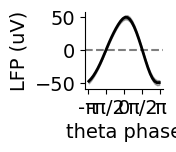

In [12]:
f1, ax = plt.subplots(1, 1, figsize=(1, 1))
tm.plot_theta_aligned_lfp(theta_aligned_signal, ax=ax, color="black")
# f1.savefig("../results/distance_to_goal/figures/supp/theta_aligned_for_key.pdf")

In [13]:
# load all distance tuning curves split by theta phase (peak and trough)
tuning_curves, tuning_metrics = tmt.get_population_theta_split_distance_tuning(verbose=False)

frames.navigation.parquet not found for m3.2022-06-25.maze
frames.thetaSpikeCounts.parquet not found for m3.2022-06-25.maze
clusters.distanceTuningMetrics.parquet not found for m3.2022-06-25.maze
frames.navigation.parquet not found for m8.2022-07-26.maze
frames.thetaSpikeCounts.parquet not found for m8.2022-07-26.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


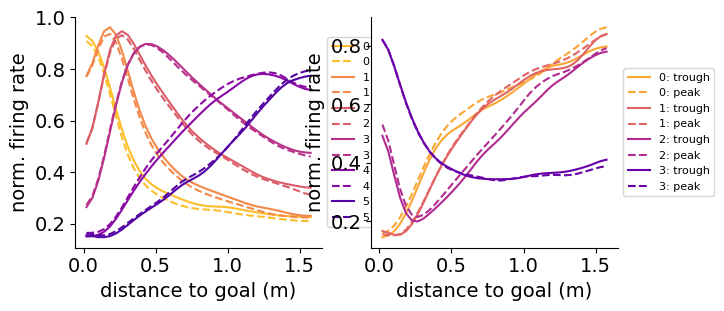

In [14]:
f, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, sign, neuron_groups in zip(axes, ["pos", "neg"], [6, 4]):
    tmt.plot_heatmap_slices(
        tuning_curves,
        tuning_metrics,
        sign=sign,
        neuron_groups=neuron_groups,
        distance_groups=False,
        how="horizontal",
        cmap="plasma_r",
        ax=ax,
    )
# f.savefig("../results/distance_to_goal/figures/supp/theta_mod_tuning_curves.pdf")

t-test: t = -4.778, p = 0.002


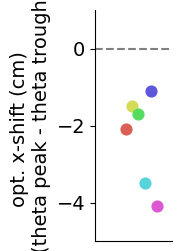

In [15]:
# random effects statistical test, how much to we need to shift peak and trough
# tuning curves to get them to align?
reload(tmt)
f, ax = plt.subplots(1, 1, figsize=(1, 3))
tmt.plot_subject_theta_x_shifts(ax=ax, print_stats=True)
# f.savefig("../results/distance_to_goal/figures/supp/theta_mod_tuning_stats.pdf")